In [1]:
import sys

sys.path.append('../')
from const import *
from train import *

In [10]:
forecasts_path = MODELS_PATH / '2025-03-31_11-55-24/forecasts_383.pkl'
sabmit_path = OUTPATH / f'{forecasts_path.parent.name}_{forecasts_path.stem}_median.csv'
with open(forecasts_path, 'rb') as f:
    forecasts = pickle.load(f)
forecasts = np.vstack(forecasts)
forecast_median = np.median(forecasts, 1)
forecast_median = np.expm1(forecast_median)
forecast_median = sum([list(data) for data in forecast_median], [])

In [16]:
for index in range(10):
    forecasts_percentile = [
        data[np.delete(np.arange(100), np.unique(np.where((data<np.percentile(data, 10-index, axis=0)) | (data>np.percentile(data, 90+index, axis=0)))[0])),:]
        for data in forecasts
    ]
    len_list = [len(data)for data in forecasts_percentile]
    if min(len_list)>10:
        print('Percentile = [%d, %d]'%(10-index, 90+index))
        break
forecasts_percentile = [np.expm1(np.median(data, axis=0)) for data in forecasts]

Percentile = [5, 95]


In [11]:
sabmit = pd.read_csv(SAMPLE_SUBMIT)
sabmit['predict'] = forecast_median
sabmit.loc[sabmit['predict']<0, 'predict'] = 0.0
sabmit.to_csv(sabmit_path)

In [11]:
forecasts[0,:,0]

array([12.992587 , 12.430888 ,  9.471592 , 11.241949 ,  8.63646  ,
       11.673974 , 14.551403 , 12.544394 , 12.2033205, 10.648455 ,
       19.046469 , 13.340645 , 13.216732 , 13.412823 , 13.332004 ,
       12.744718 , 12.414494 , 12.449538 , 14.628015 , 14.76484  ,
       21.73345  , 14.277115 , 13.572344 , 12.809021 , 12.020082 ,
       11.32231  , 11.966589 , 16.228703 , 12.960009 , 12.939597 ,
       15.867334 , 11.383496 , 12.162196 ,  4.518439 , 16.352938 ,
       10.276219 ,  9.703865 ,  4.4541926, 11.990662 ,  8.870122 ,
       12.837578 , 17.925686 , 11.985294 , 12.471423 , 12.09725  ,
       11.527516 , 12.439339 , 14.212847 , 13.907483 , 13.057153 ,
       12.847888 , 20.52787  ,  8.280032 , 17.12935  , 13.997374 ,
       14.7459545, 13.3273535, 11.936399 , 13.235252 , 10.110087 ,
        9.862348 , 11.60362  , 12.491785 , 13.835601 , 11.031438 ,
       12.345342 ,  6.361052 , 13.326044 ,  9.606518 , 11.896735 ,
       16.627914 ,  9.949387 , 11.993651 , 17.347395 , 12.6046

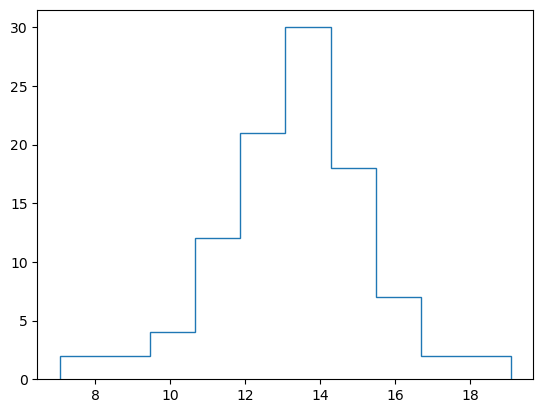

In [16]:
import matplotlib.pyplot as plt
counts, bins = np.histogram(forecasts[0,:,0])
plt.stairs(counts, bins)

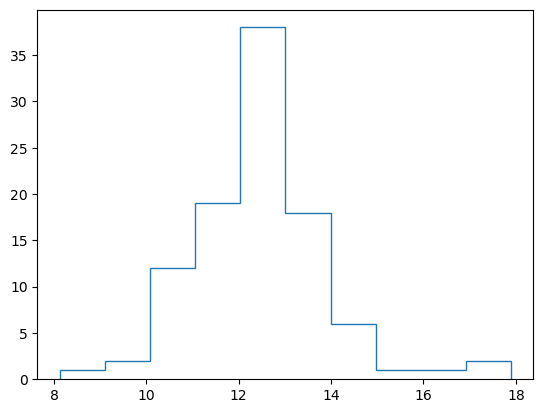

In [5]:
import matplotlib.pyplot as plt
counts, bins = np.histogram(forecasts[0,:,0])
plt.stairs(counts, bins)

In [6]:
config = get_config()
train_dataset, val_dataset, predict_dataset = load_dataset(DATASET_WEEK_PATH)
train_dataloader, val_dataloader, predict_dataloader = get_dataloader(
    train_dataset, val_dataset, predict_dataset, config
)

In [9]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

def plot(ts_index):
    fig, ax = plt.subplots()

    index = pd.period_range(
        start=predict_dataset[ts_index][FieldName.START],
        periods=len(predict_dataset[ts_index][FieldName.TARGET]),
        freq=FREQ,
    ).to_timestamp()

    # Major ticks every half year, minor ticks every month,
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    ax.plot(
        index[-65:], 
        10**np.array(predict_dataset[ts_index]["target"][-65:])-1,
        label="actual",
    )

    plt.plot(
        index[-PREDICTION_LENGTH:], 
        10**np.array(np.median(forecasts[ts_index], axis=0))-1,
        label="median",
    )
    plt.fill_between(
        index[-PREDICTION_LENGTH:],
        10**forecasts[ts_index].mean(0) - 10**forecasts[ts_index].std(axis=0), 
        10**forecasts[ts_index].mean(0) + 10**forecasts[ts_index].std(axis=0), 
        alpha=0.3, 
        interpolate=True,
        label="+/- 1-std",
    )
    plt.legend()
    plt.show()

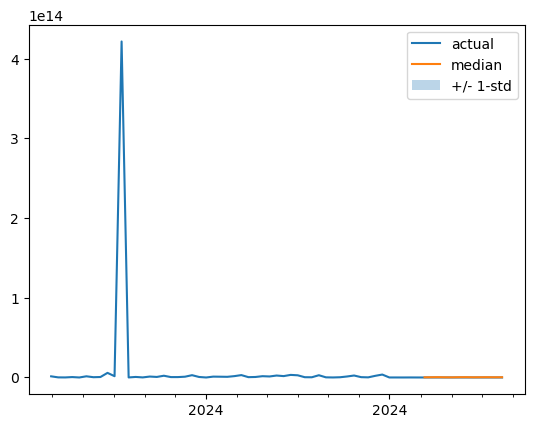

In [10]:
plot(34332)

In [1]:
12321 // 80 * 80

12320

In [2]:
96// 80 * 80

80